# Term Deposit Subscription Prediction

## Introduction

Term deposits are one of the most widely offered investment products in the banking sector. Banks conduct direct marketing campaigns to encourage customers to subscribe to these deposits, but only a limited number of customers respond positively. Predicting customer subscription behavior helps financial institutions improve marketing efficiency and optimize campaign costs.

This project uses the **Bank Marketing Dataset** from the **UCI Machine Learning Repository** to analyze customer demographic information, financial characteristics, and previous marketing campaign data. The dataset is explored, cleaned, and preprocessed to prepare it for machine learning.

Machine learning classification models are developed to predict whether a customer will subscribe to a term deposit. The models are evaluated using multiple performance metrics, and Explainable AI (SHAP) is used to interpret model predictions and identify the factors influencing customer decisions.

## Problem Statement

Banks invest significant resources in direct marketing campaigns to promote term deposit subscriptions. However, contacting every customer does not guarantee a positive response, making these campaigns both time-consuming and costly.

The challenge is to accurately identify customers who are more likely to subscribe to a term deposit based on their demographic information, financial characteristics, and previous marketing interactions. Developing a predictive model can help banks target the right customers, improve campaign efficiency, and support data-driven marketing decisions.

## Project Objectives

The main objectives of this project are:

- Understand the structure and characteristics of the Bank Marketing dataset.
- Perform data cleaning and preprocessing to prepare the dataset for analysis.
- Explore customer behavior using Exploratory Data Analysis (EDA).
- Encode categorical variables for machine learning models.
- Develop classification models to predict term deposit subscription.
- Evaluate model performance using appropriate classification metrics.
- Compare different machine learning models to identify the best-performing model.
- Interpret model predictions using Explainable AI (SHAP).
- Generate meaningful business insights and recommendations based on the analysis.

## Dataset Information

This project uses the **Bank Marketing Dataset** obtained from the **UCI Machine Learning Repository**.

**Dataset Source:**  
https://archive.ics.uci.edu/dataset/222/bank+marketing

The dataset contains customer demographic information, financial details, and marketing campaign records collected during direct marketing campaigns conducted by a Portuguese banking institution.

The primary objective of this dataset is to analyze customer characteristics and predict whether a customer will subscribe to a term deposit based on demographic, financial, and campaign-related features.

Each record represents an individual bank customer and includes information such as age, job, marital status, education, account balance, housing loan, personal loan, contact type, campaign duration, previous campaign outcomes, and other relevant customer attributes.

The target variable in this dataset is **y**, where **"yes"** indicates that the customer subscribed to a term deposit and **"no"** indicates that the customer did not subscribe.

### Target Variable

| Value | Meaning |
|--------|---------|
| no | Customer did not subscribe to the term deposit |
| yes | Customer subscribed to the term deposit |

### Dataset Summary

| Attribute | Description |
|------------|------------|
| Dataset Name | Bank Marketing Dataset |
| Source | UCI Machine Learning Repository |
| File Used | bank-full.csv |
| Problem Type | Binary Classification |
| Target Variable | y |
| Domain | Banking and Marketing |

## Dataset Understanding and Description

Understanding the dataset is an essential step before performing data cleaning, exploratory data analysis, and machine learning model development.

This project uses the **Bank Marketing Dataset**, which contains customer demographic information, financial details, and marketing campaign-related attributes collected during direct marketing campaigns conducted by a Portuguese banking institution.

The objective is to predict whether a customer is likely to subscribe to a term deposit based on demographic information, financial characteristics, and previous marketing campaign interactions.


### Dataset Features

| Feature | Description |
|----------|-------------|
| age | Customer age |
| job | Type of job |
| marital | Marital status |
| education | Education level |
| default | Credit in default status |
| balance | Average yearly account balance |
| housing | Housing loan status |
| loan | Personal loan status |
| contact | Communication contact type |
| day | Last contact day of the month |
| month | Last contact month |
| duration | Duration of the last contact (seconds) |
| campaign | Number of contacts during the current campaign |
| pdays | Number of days since the customer was last contacted |
| previous | Number of contacts before the current campaign |
| poutcome | Outcome of the previous marketing campaign |
| y | Target variable indicating term deposit subscription |


## Import Required Libraries

Before beginning the data analysis and machine learning process, the required Python libraries are imported.

These libraries provide essential functionalities for data loading, preprocessing, visualization, classification modeling, performance evaluation, and explainable artificial intelligence (XAI).

Pandas and NumPy are used for data manipulation and numerical computations.

Matplotlib and Seaborn are used to create visualizations for exploratory data analysis.

Scikit-learn is used for data preprocessing, model training, prediction, and performance evaluation. SHAP is used to interpret machine learning models by explaining how individual features contribute to model predictions.

In [1]:
# Data Manipulation

import pandas as pd
import numpy as np

# Data Visualization

import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Model Evaluation

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    f1_score,
    roc_curve,
    roc_auc_score
)

# Explainable AI

import shap

## Load Dataset

The Bank Marketing Dataset is loaded into a Pandas DataFrame for analysis.

A DataFrame is a tabular data structure consisting of rows and columns, similar to an Excel spreadsheet. It allows efficient data exploration, manipulation, and analysis.

A copy of the original dataset is also created to preserve the raw data while performing data cleaning and preprocessing operations.

In [2]:
# Load dataset into a Pandas DataFrame

df = pd.read_csv("../dataset/bank-full.csv", sep=";")

# Create a copy of the original dataset

df_copy = df.copy()

## Dataset Preview

After loading the dataset, the first five records are displayed to verify that the dataset has been loaded successfully and to gain an initial understanding of its structure.

In [3]:
# Display first five records

df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [4]:
# Display the first five records of the copied dataset

df_copy.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


## Data Cleaning and Preparation

Data cleaning is an important step in the machine learning workflow.

The objective of this phase is to identify missing values, verify dataset quality, and prepare the data for analysis and model development.

### Dataset Shape

Understanding the size of the dataset is an important step before performing data cleaning and analysis.

The shape of the dataset provides information about the total number of records and features available for term deposit subscription prediction. This helps estimate the overall dataset size and understand the amount of information available for machine learning model development.

In [5]:
# Display the shape of the dataset

df.shape

(45211, 17)

#### Observation

The dataset contains **45,211 records** and **17 columns**.

The dataset is sufficiently large for machine learning tasks and contains a diverse set of customer demographic, financial, and marketing campaign attributes that can be used to predict term deposit subscription.

### Dataset Information

The dataset information is examined to understand the dataset structure, including the number of entries, column names, data types, and non-null values. This helps identify missing values before data preprocessing.

In [6]:
# Display dataset information

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   age        45211 non-null  int64
 1   job        45211 non-null  str  
 2   marital    45211 non-null  str  
 3   education  45211 non-null  str  
 4   default    45211 non-null  str  
 5   balance    45211 non-null  int64
 6   housing    45211 non-null  str  
 7   loan       45211 non-null  str  
 8   contact    45211 non-null  str  
 9   day        45211 non-null  int64
 10  month      45211 non-null  str  
 11  duration   45211 non-null  int64
 12  campaign   45211 non-null  int64
 13  pdays      45211 non-null  int64
 14  previous   45211 non-null  int64
 15  poutcome   45211 non-null  str  
 16  y          45211 non-null  str  
dtypes: int64(7), str(10)
memory usage: 5.9 MB


#### Observation

The dataset contains **45,211 records** and **17 features**. All features have **45,211 non-null values**, indicating that there are **no missing values** in the dataset. The dataset includes **7 numerical features** and **10 categorical features**, making it suitable for data preprocessing and machine learning model development.

### Duplicate Records

Duplicate records are checked to ensure data quality before performing exploratory data analysis and machine learning. Removing duplicate records helps prevent biased analysis and improves model reliability.

In [7]:
# Check duplicate records

print("Duplicate Records: ", df.duplicated().sum())

Duplicate Records:  0


#### Observation

No duplicate records were found in the dataset. Therefore, no duplicate rows need to be removed before proceeding with data analysis and machine learning.

## Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) is performed to understand the characteristics of the dataset, identify patterns, and discover meaningful insights from customer and marketing campaign data.

The insights obtained during EDA help understand customer behavior and support the development of effective machine learning models for term deposit subscription prediction.

### Descriptive Statistics

Descriptive statistics provide a statistical summary of the numerical features in the dataset, including measures such as count, mean, standard deviation, minimum, maximum, and quartiles.

This helps understand the overall distribution and characteristics of the numerical variables before visualization and model development.

In [8]:
# Display descriptive statistics of numerical features

df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


#### Observation

The numerical features exhibit considerable variation in their distributions. The average customer age is approximately **41 years**, while the average account balance is around **1,362**. Marketing campaign-related variables such as **duration**, **campaign**, and **previous** show a wide range of values, indicating variability in customer interactions. Some numerical features also contain extreme values, which will be examined further during outlier analysis.

### Term Deposit Subscription Distribution

The target variable (**y**) indicates whether a customer subscribed to a term deposit after the marketing campaign.

Analyzing its distribution helps understand the class balance in the dataset before developing machine learning models.

In [10]:
# Display the distribution of the target variable

df["y"].value_counts()

y
no     39922
yes     5289
Name: count, dtype: int64

#### Term Deposit Subscription Distribution Visualization

A bar chart is used to visualize the distribution of customers who subscribed and did not subscribe to a term deposit.

This visualization provides a clear comparison between the two target classes and highlights the overall class distribution.

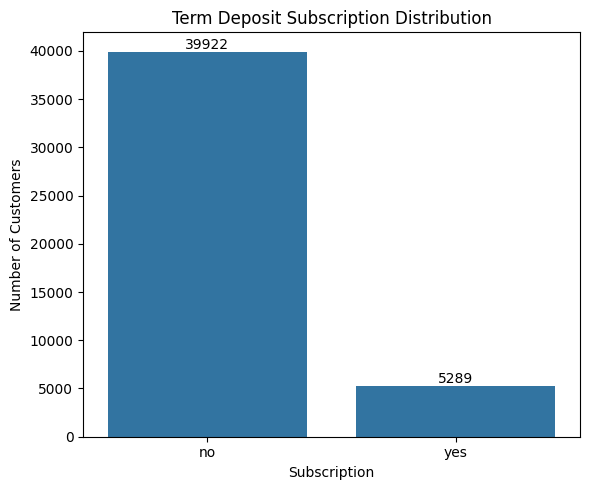

In [32]:
# Plot the distribution of the target variable

plt.figure(figsize=(6, 5))

ax = sns.countplot(
    data=df,
    x="y"
)

# Add data labels
ax.bar_label(ax.containers[0])

plt.title("Term Deposit Subscription Distribution")
plt.xlabel("Subscription")
plt.ylabel("Number of Customers")

# Save figure
plt.tight_layout()

# plt.savefig(
#     "../outputs/figures/01_term_deposit_subscription_distribution.png",
#     dpi=300,
#     bbox_inches="tight"
# )

plt.show()

#### Observation

The target variable distribution indicates that **39,922** customers did not subscribe to a term deposit, while only **5,289** customers subscribed. This shows that the dataset is **imbalanced**, with the majority of customers belonging to the **'no'** class. Therefore, model performance should be evaluated using metrics such as **F1-score**, **ROC-AUC**, and the **Confusion Matrix**, rather than relying solely on accuracy.

### Age Distribution

The **age** feature represents the age of each customer in the dataset.

Analyzing its distribution helps understand the age profile of customers and identify any unusual patterns or potential outliers before model development.

In [13]:
# Display summary statistics for age

df["age"].describe()

count    45211.000000
mean        40.936210
std         10.618762
min         18.000000
25%         33.000000
50%         39.000000
75%         48.000000
max         95.000000
Name: age, dtype: float64

#### Age Distribution Visualization

A histogram is used to visualize the distribution of customer ages.

This visualization helps understand the frequency of different age groups and identify the overall distribution pattern.

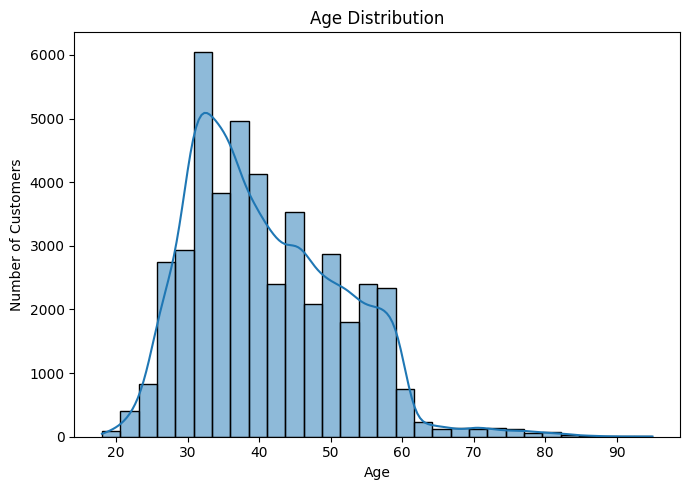

In [22]:
# Plot the age distribution

plt.figure(figsize=(7, 5))

sns.histplot(
    data=df,
    x="age",
    bins=30,
    kde=True
)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Customers")

# Save figure
plt.tight_layout()

# plt.savefig(
#     "../outputs/figures/02_age_distribution.png",
#     dpi=300,
#     bbox_inches="tight"
# )

plt.show()

#### Observation

The age distribution shows that most customers are between **30 and 50 years** of age, with the highest concentration in the early **30s**. The distribution is **positively skewed (right-skewed)**, indicating that the number of customers gradually decreases as age increases. A relatively small number of customers are above **60 years** of age, suggesting that older customers represent a smaller portion of the dataset.

### Age Box Plot

A box plot is used to visualize the spread of customer ages and identify potential outliers.

It provides a summary of the age distribution based on the median, quartiles, and extreme values.

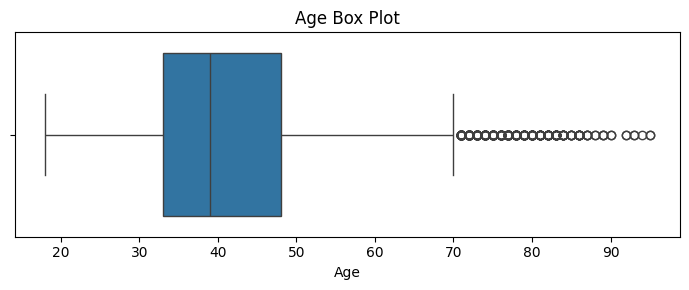

In [21]:
# Plot the age box plot

plt.figure(figsize=(7, 3))

sns.boxplot(
    data=df,
    x="age"
)

plt.title("Age Box Plot")
plt.xlabel("Age")

# Save figure
plt.tight_layout()

# plt.savefig(
#     "../outputs/figures/03_age_boxplot.png",
#     dpi=300,
#     bbox_inches="tight"
# )

plt.show()

#### Observation

The box plot indicates that the majority of customers are between approximately **33 and 49 years** of age, with a median age of around **39 years**. Several **upper outliers** are present beyond the age of **70**, indicating a small number of older customers in the dataset. No significant lower outliers are observed.

### Job Distribution

The **job** feature represents the occupation of each customer included in the marketing campaign.

Analyzing the distribution of customer occupations helps understand the composition of the dataset and identify the most common customer groups.

In [23]:
# Display the distribution of customer occupations

df["job"].value_counts()

job
blue-collar      9732
management       9458
technician       7597
admin.           5171
services         4154
retired          2264
self-employed    1579
entrepreneur     1487
unemployed       1303
housemaid        1240
student           938
unknown           288
Name: count, dtype: int64

#### Job Distribution Visualization

A bar chart is used to visualize the distribution of customer occupations.

This visualization provides a clear comparison of the number of customers in each job category.

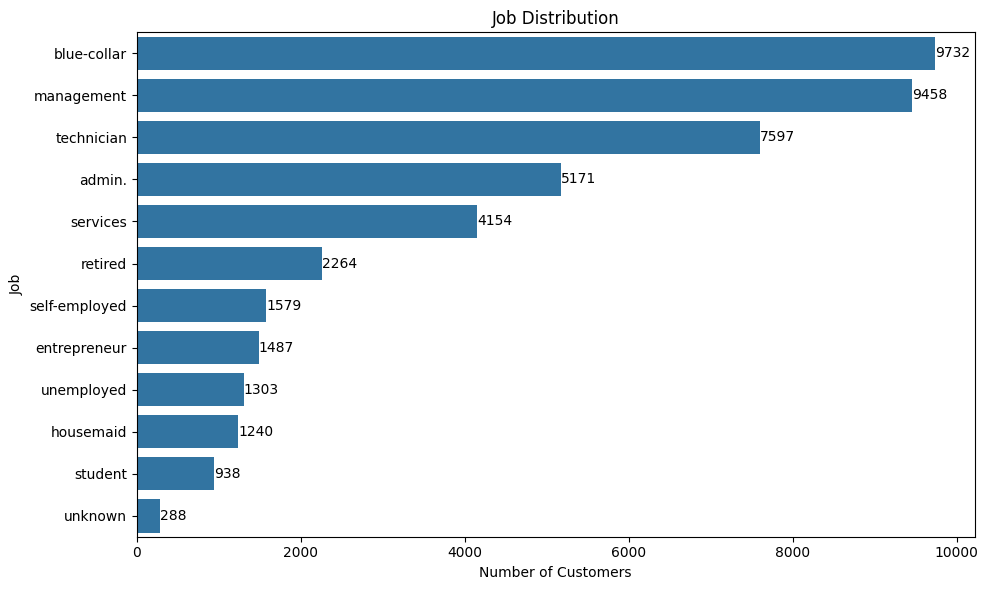

In [31]:
# Plot the distribution of customer occupations

# For Proper Order
job_counts = df["job"].value_counts()

plt.figure(figsize=(10, 6))

ax = sns.countplot(
    data=df,
    y="job",
    order=job_counts.index
)

# Add data labels
ax.bar_label(ax.containers[0])

plt.title("Job Distribution")
plt.xlabel("Number of Customers")
plt.ylabel("Job")

# Save figure
plt.tight_layout()

# plt.savefig(
#     "../outputs/figures/04_job_distribution.png",
#     dpi=300,
#     bbox_inches="tight"
# )

plt.show()

#### Observation

The job distribution indicates that **blue-collar (9,732)** and **management (9,458)** are the most common occupations in the dataset, followed by **technician (7,597)** and **admin. (5,171)**. Occupations such as **student (938)** and **unknown (288)** have the lowest representation. This suggests that the dataset is primarily composed of working professionals from blue-collar, management, and technical occupations.

### Term Deposit Subscription Rate by Job

Customer occupation can influence financial behavior and response to marketing campaigns.

This analysis examines the **subscription rate** across different job categories to identify which occupational groups are more likely to subscribe to a term deposit.

In [37]:
# Calculate subscription rate (%) for each job category

subscription_rate = (
    pd.crosstab(
        df["job"],
        df["y"],
        normalize="index"
    )["yes"] * 100
).sort_values(ascending=False)

subscription_rate.round(2)

job
student          28.68
retired          22.79
unemployed       15.50
management       13.76
admin.           12.20
self-employed    11.84
unknown          11.81
technician       11.06
services          8.88
housemaid         8.79
entrepreneur      8.27
blue-collar       7.27
Name: yes, dtype: float64

#### Term Deposit Subscription Rate by Job Visualization

A horizontal bar chart is used to compare the percentage of customers who subscribed to a term deposit across different job categories.

The job categories are arranged in descending order of subscription rate, making it easier to identify the occupations with the highest and lowest conversion rates.

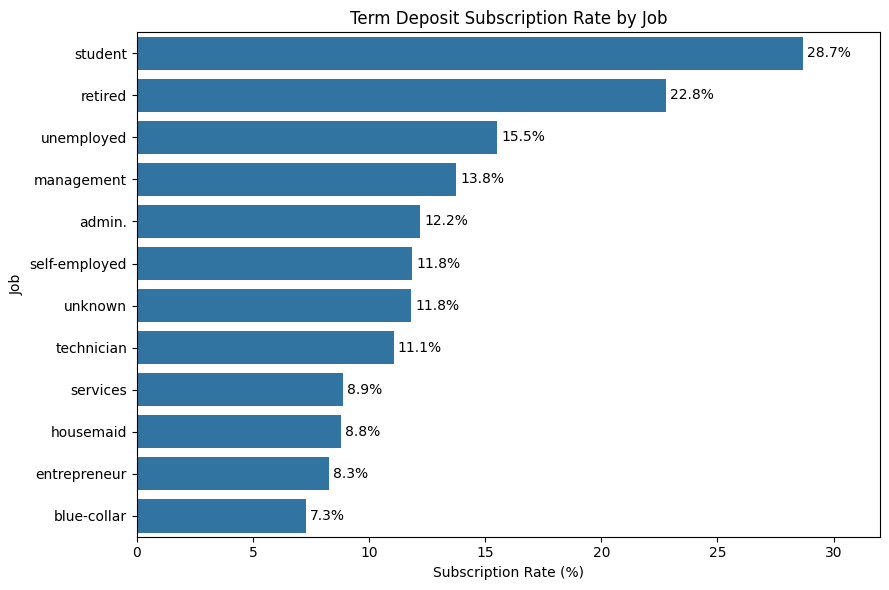

In [47]:
# Plot subscription rate by job category

plt.figure(figsize=(9, 6))

ax = sns.barplot(
    x=subscription_rate.values,
    y=subscription_rate.index
)

# Add percentage labels
ax.bar_label(
    ax.containers[0],
    fmt="%.1f%%",
    padding=3
)

# Add extra space for labels
plt.xlim(0, 32)

plt.title("Term Deposit Subscription Rate by Job")
plt.xlabel("Subscription Rate (%)")
plt.ylabel("Job")

# Save figure
plt.tight_layout()

plt.savefig(
    "../outputs/figures/05_subscription_rate_by_job.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()